<a href="https://colab.research.google.com/github/Gurirath/VIT---EDA---Projects---Classwork--25BAI0153/blob/main/Exp5_18_8_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
df = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/data.csv")

In [2]:
print(df.head(3))
print(df.tail(3))
print(df.dtypes)
print(df.describe())
print(pd.isna(df).any())

   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        std          two   
1          3                 ?  alfa-romero       gas        std          two   
2          1                 ?  alfa-romero       gas        std          two   

    body-style drive-wheels engine-location  wheel-base  ...  engine-size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   

   fuel-system  bore  stroke compression-ratio horsepower  peak-rpm city-mpg  \
0         mpfi  3.47    2.68               9.0        111      5000       21   
1         mpfi  3.47    2.68               9.0        111      5000       21   
2         mpfi  2.68    3.47               9.0        154      5000       19   

  highway-mpg  price  
0          27  13495  

In [3]:
print(df['price'].str.isnumeric().value_counts())
print(df['price'].loc[df['price'].str.isnumeric() == False])
price = df['price'].loc[df['price'] != '?']
pmean = price.astype(int).mean()
df['price'] = df['price'].replace('?', pmean).astype(int)
print(df['price'].head(10))

price
True     201
False      4
Name: count, dtype: int64
9      ?
44     ?
45     ?
129    ?
Name: price, dtype: object
0    13495
1    16500
2    16500
3    13950
4    17450
5    15250
6    17710
7    18920
8    23875
9    13207
Name: price, dtype: int64


In [4]:
horsepower = df['horsepower'].loc[df['horsepower'] != '?']
hpmean = horsepower.astype(int).mean()
df['horsepower'] = df['horsepower'].replace('?', hpmean).astype(int)
nl = df['normalized-losses'].loc[df['normalized-losses'] != '?']
nmean = nl.astype(int).mean()
df['normalized-losses'] = df['normalized-losses'].replace('?', nmean).astype(int)

In [5]:
mean = df["height"].mean()
median = df["height"].median()
mode = df["height"].mode()
print(mean, median, mode)

53.72487804878049 54.1 0    50.8
Name: height, dtype: float64


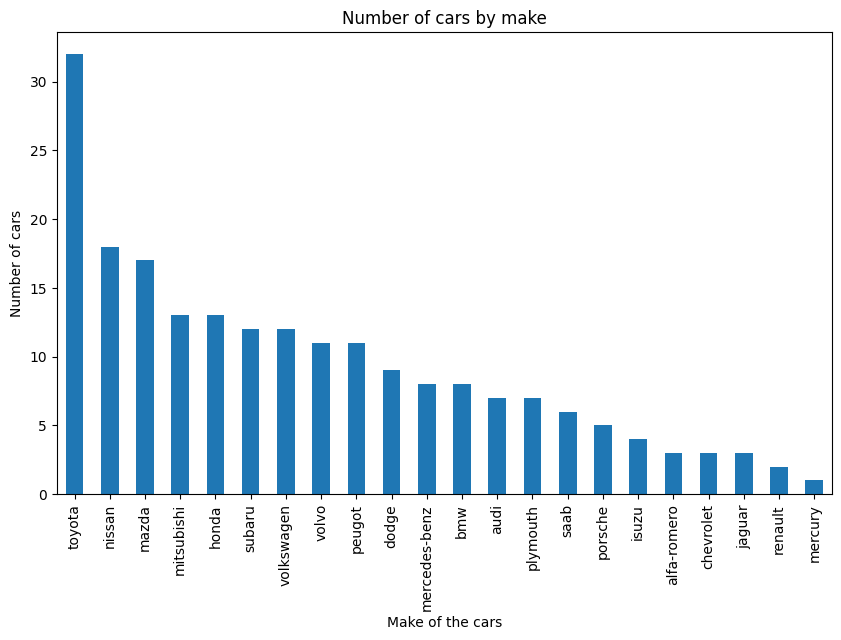

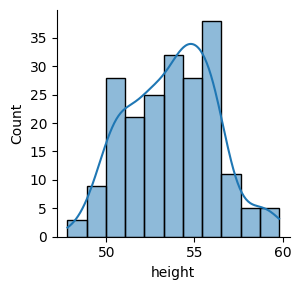

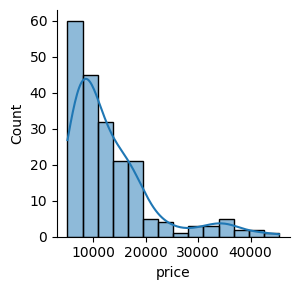

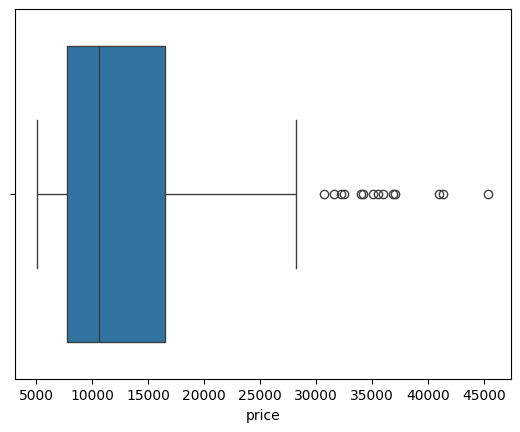

In [6]:
df.make.value_counts().nlargest(30).plot(kind='bar', figsize=(10, 6))
plt.title("Number of cars by make")
plt.ylabel('Number of cars')
plt.xlabel('Make of the cars')
plt.show()
sns.FacetGrid(df).map(sns.histplot, "height", kde=True).add_legend()
plt.show()
sns.FacetGrid(df).map(sns.histplot, "price", kde=True).add_legend()
plt.show()
sns.boxplot(x="price", data=df)
plt.show()

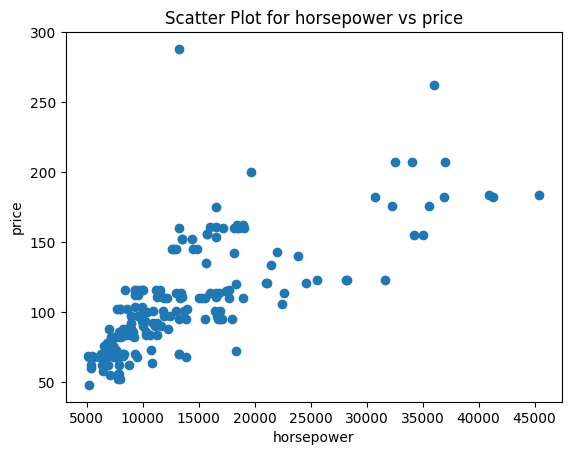

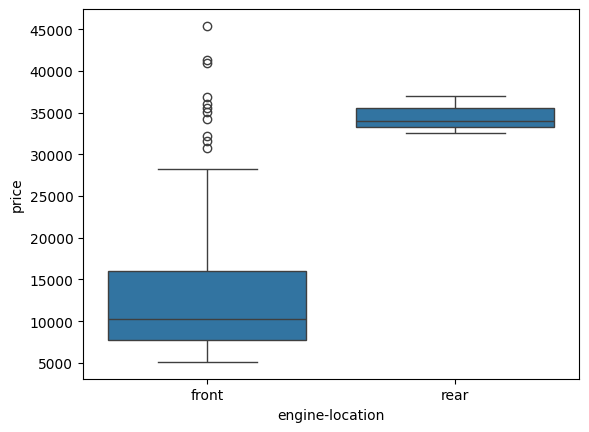

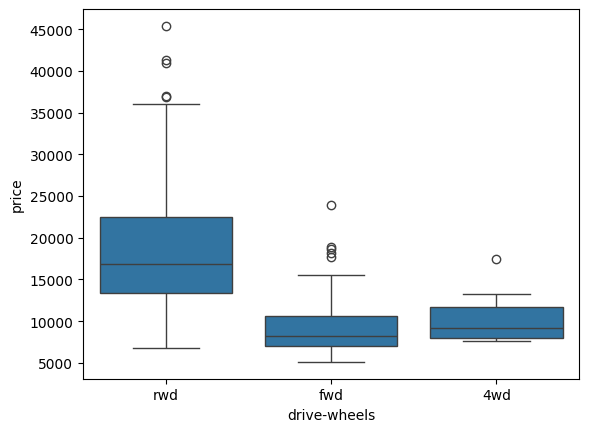

In [7]:
plt.scatter(df["price"], df["horsepower"])
plt.title("Scatter Plot for horsepower vs price")
plt.xlabel("horsepower")
plt.ylabel("price")
plt.show()
sns.boxplot(x="engine-location", y="price", data=df)
plt.show()
sns.boxplot(x="drive-wheels", y="price", data=df)
plt.show()

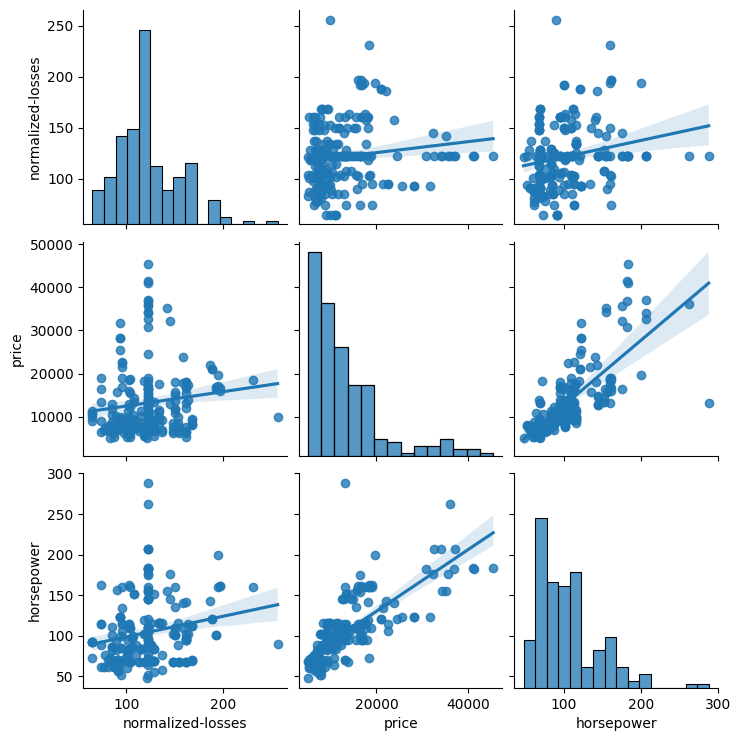

In [8]:
sns.pairplot(df, vars=['normalized-losses', 'price', 'horsepower'], kind="reg")
plt.show()

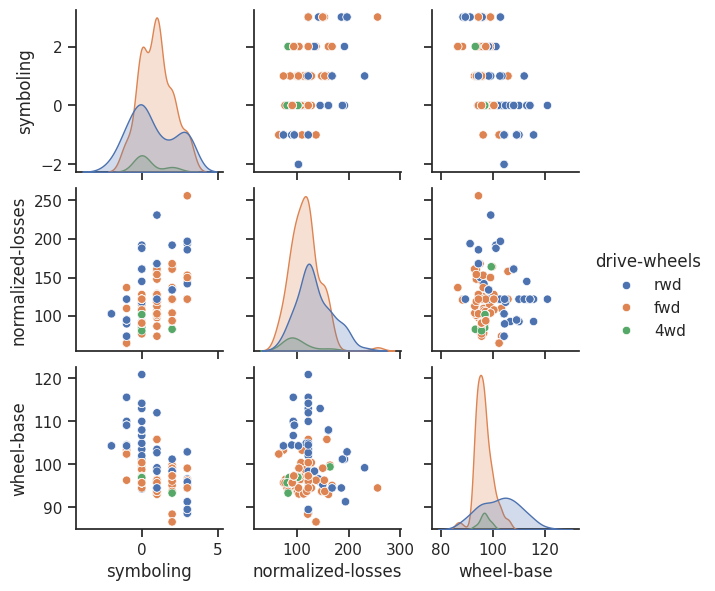

In [9]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['symboling', 'normalized-losses', 'wheel-base'], hue="drive-wheels")
plt.show()

p-value:	 1.5910332446595894e-39
cor:		 0.757945621793524
                   symboling  normalized-losses  wheel-base    length  \
symboling           1.000000           0.465190   -0.531954 -0.357612   
normalized-losses   0.465190           1.000000   -0.056518  0.019209   
wheel-base         -0.531954          -0.056518    1.000000  0.874587   
length             -0.357612           0.019209    0.874587  1.000000   
width              -0.232919           0.084195    0.795144  0.841118   
height             -0.541038          -0.370706    0.589435  0.491029   
curb-weight        -0.227691           0.097785    0.776386  0.877728   
engine-size        -0.105790           0.110997    0.569329  0.683360   
compression-ratio  -0.178515          -0.114525    0.249786  0.158414   
horsepower          0.071380           0.203434    0.351985  0.554408   
city-mpg           -0.035823          -0.218749   -0.470414 -0.670909   
highway-mpg         0.034606          -0.178221   -0.544082 -0.704

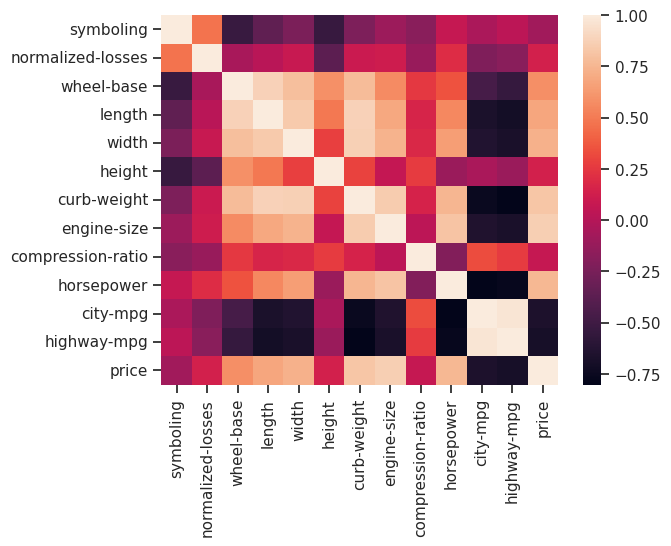

In [10]:
corr = stats.pearsonr(df["price"], df["horsepower"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)
plt.show()